# Working with `COMSOL` scattering model solver with `mph` module

In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

import mph

from src.cylinder import SingleCylinder, build_cylinders, plot_shape
from src.prepare_model import CYL_HEIGHT, CYL_DIAMETER, N_CYL
from src.ab_multipoles import MULTIPOLES_TM, MULTIPOLES_TE, M, eval_ab

In [2]:
outdir = Path("output")
outdir.mkdir(exist_ok=True)

## upload model

In [3]:
# # preparing model if not already done
# !uv run python -m src.prepare_model

In [4]:
# load prepared model
client = mph.start()
model = client.load('models/model.mph')

In [5]:
mph.tree(model)

model
├─ parameters
│  └─ Parameters 1
├─ functions
│  ├─ n_GaAs
│  ├─ k_GaAs
│  ├─ Analytic 1
│  ├─ Roots of Bessel Function Derivatives
│  └─ Roots of Bessel Functions
├─ components
│  └─ Component 1
├─ geometries
│  └─ Geometry 1
│     ├─ Circle 1
│     ├─ Circle 2
│     ├─ Polygon 1
│     └─ Form Union
├─ views
│  └─ View 1
├─ selections
├─ coordinates
│  ├─ Boundary System 1
│  └─ Perfectly Matched Layer 1
├─ variables
│  ├─ wavenumber
│  ├─ background field TE
│  ├─ background field TM
│  ├─ current
│  ├─ EL DIPOLE
│  ├─ EL QUADROPOLE
│  ├─ EL OCTOPOLE
│  ├─ EL 4-th order multipole
│  ├─ MG DIPOLE
│  ├─ MG QUADROPOLE
│  ├─ MG OCTOPOLE
│  ├─ MG 4-th order multipole
│  ├─ scattering
│  └─ full fields
├─ couplings
│  ├─ Integration_volume
│  ├─ Integration_surface
│  ├─ Wave Equation Feature Integration
│  ├─ Integration over non-PML domains
│  └─ root.comp1.ewfd2.wee1.pml1.intop
├─ physics
│  ├─ Electromagnetic Waves, Frequency Domain TE
│  │  ├─ Wave Equation, Electric 1
│  │  ├─ 

In [6]:
model.parameters()

{'lambda_w': '1550[nm]',
 'theta': '30[deg]',
 'k1': '2*pi/lambda_w',
 'k1x': 'k1*sin(theta)',
 'Etm': '1[V/m]',
 'Ete': '1[V/m]',
 'Etmx': 'Etm*cos(theta)',
 'Etmz': 'Etm*sin(theta)',
 'M': '2',
 'r_air': '1.6[um]',
 'h_sub': '600[nm]',
 'pml': '1*lambda_w',
 'nu': 'c_const/lambda_w',
 'eta': 'mu0_const*c_const',
 'cyl_h': '800[nm]',
 'diam_cyl': '600[nm]',
 'phi_cut': '0[rad]'}

## update geometry

In [7]:
# during optimization we will update the geometry by changing the coordinates of the polygon vertices

rng = np.random.default_rng(seed=24)
r = (CYL_DIAMETER - CYL_DIAMETER / 3 * (rng.random(N_CYL) - 0.5)) / 2
cylinders = [SingleCylinder(h=CYL_HEIGHT / N_CYL, r=ri) for ri in r]

build_cylinders(model, cylinders)

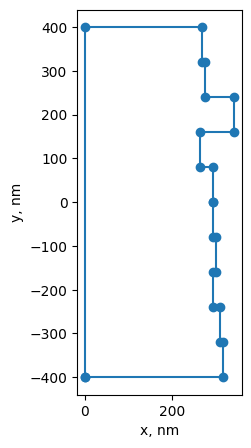

In [8]:
plot_shape(model)

## multipole coefficients evaluation

In [9]:
# solve scattering problem
model.solve()

In [10]:
result_te = eval_ab(model=model, pol='te', multipoles=MULTIPOLES_TE)
# result_tm = eval_ab(model=model, pol='tm', multipoles=MULTIPOLES_TM)

In [11]:
for n in range(1, M + 1):
    for m in range(-n, n+1):
        print(f"a{n}{m} = {result_te['a'][n][m]:.2e}, b{n}{m} = {result_te['b'][n][m]:.2e}")

a1-1 = 1.83e-04+9.09e-04j, b1-1 = -1.49e-03-1.43e-03j
a10 = 0.00e+00, b10 = -7.77e-04+3.20e-03j
a11 = 1.83e-04+9.09e-04j, b11 = 1.49e-03+1.43e-03j
a2-2 = 8.37e-04+1.26e-03j, b2-2 = -2.71e-03-1.53e-03j
a2-1 = 4.76e-03-2.90e-03j, b2-1 = 1.41e-06+5.61e-04j
a20 = 0.00e+00, b20 = 2.07e-03+3.98e-04j
a21 = 4.76e-03-2.90e-03j, b21 = -1.41e-06-5.61e-04j
a22 = -8.37e-04-1.26e-03j, b22 = -2.71e-03-1.53e-03j
a3-3 = 1.74e-05-7.34e-07j, b3-3 = -1.48e-06-9.38e-06j
a3-2 = 1.52e-04-1.64e-05j, b3-2 = -2.30e-04-2.55e-04j
a3-1 = 1.54e-04-4.16e-05j, b3-1 = -6.85e-05+2.28e-04j
a30 = 0.00e+00, b30 = 5.20e-04+7.79e-04j
a31 = 1.54e-04-4.16e-05j, b31 = 6.85e-05-2.28e-04j
a32 = -1.52e-04+1.64e-05j, b32 = -2.30e-04-2.55e-04j
a33 = 1.78e-05-4.16e-07j, b33 = 1.48e-06+9.38e-06j
a4-4 = -2.09e-09-2.43e-07j, b4-4 = -7.64e-08+1.26e-08j
a4-3 = -1.30e-07-5.42e-06j, b4-3 = -4.19e-07-5.24e-07j
a4-2 = 4.13e-05+4.43e-05j, b4-2 = -6.50e-05-3.66e-05j
a4-1 = 1.07e-04-6.88e-05j, b4-1 = 9.37e-05-7.68e-06j
a40 = 0.00e+00, b40 = 5.4

## save results

In [12]:
# save the results
with open("output/target.pkl", "wb") as f:
    pickle.dump(result_te, f)

In [13]:
# this is exactly how the target was created
with open("target.pkl", "rb") as f:
    target = pickle.load(f)

target

{'a': {1: {-1: np.complex128(0.00018294780053721387+0.0009092786950531909j),
   0: np.float64(0.0),
   1: np.complex128(0.00018294780053961857+0.0009092786950501765j)},
  2: {-2: np.complex128(0.0008368591844054511+0.0012608451829857225j),
   -1: np.complex128(0.004760915172613583-0.0029030705848805552j),
   0: np.float64(0.0),
   1: np.complex128(0.004760915172612485-0.0029030705848803492j),
   2: np.complex128(-0.000836859184405491-0.0012608451829857123j)},
  3: {-3: np.complex128(1.7395557074846822e-05-7.337501557975097e-07j),
   -2: np.complex128(0.00015156625129234626-1.6440689716301404e-05j),
   -1: np.complex128(0.00015392114989991624-4.163186384576144e-05j),
   0: np.float64(0.0),
   1: np.complex128(0.00015392114990018458-4.1631863847005655e-05j),
   2: np.complex128(-0.00015156625129234742+1.644068971630189e-05j),
   3: np.complex128(1.7775984523381184e-05-4.155931283065781e-07j)},
  4: {-4: np.complex128(-2.091915068167021e-09-2.4283329028966466e-07j),
   -3: np.complex128(-

In [ ]:
# save the solved model
model.save(outdir / "model_target.mph")

## Additional

magnitudes of the multipole coefficients distribution

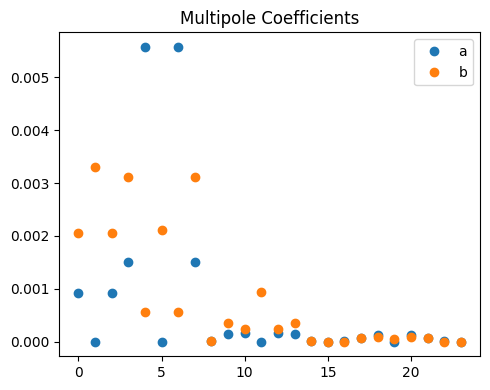

In [15]:
a_mag = np.array([
    abs(result_te["a"][n][m])
    for n in range(1, M + 1)
    for m in range(-n, n + 1)
])
# a_mag_nonzero = a_mag[a_mag > 0]

b_mag = np.array([
    abs(result_te["b"][n][m])
    for n in range(1, M + 1)
    for m in range(-n, n + 1)
])
# b_mag_nonzero = b_mag[b_mag > 0]


fig, ax = plt.subplots(figsize=(5, 4))

indexes = np.arange(len(a_mag))
ax.plot(indexes, a_mag, "o", label="a")
ax.plot(indexes, b_mag, "o", label="b")
ax.set_title("Multipole Coefficients")
ax.legend()

plt.tight_layout()
plt.show()

plotting the field distribution if the plot groups were defined (not deleted) in the model

In [16]:
def export_plot_image(model, filename, pol, width=700, height=1000):

    def plotgroup_tag_by_label(model, label):
        for tag in model.java.result().tags():
            pg = model.java.result(tag)
            if pg.label() == label:
                return tag
        raise ValueError(f"Plot group not found: {label}")

    def feature_tag_by_label(parent, label):
        for tag in parent.feature().tags():
            feat = parent.feature(tag)
            if feat.label() == label:
                return tag
        raise ValueError(f"Feature not found: {label}")

    if pol == "tm":
        pg_label = "Electric Field (ewfd)"
        expr = "Eabs_full"
    else:
        pg_label = "Electric Field (ewfd2)"
        expr = "E2abs_full"
    pg_ewfd_tag = plotgroup_tag_by_label(model, pg_label)
    pg_ewfd = model.java.result(pg_ewfd_tag)
    surf_ewfd_tag = feature_tag_by_label(pg_ewfd, "Surface 1")
    pg_ewfd.feature(surf_ewfd_tag).set("expr", expr)

    pg_ewfd.run()

    # pg_tag = plotgroup_tag_by_label(model, plot_label)
    # model.java.result(pg_ewfd_tag).setIndex("looplevel", str(m_idx), 0)
    # model.java.result(pg_ewfd_tag).run()

    exports = model.java.result().export()
    tag = "img_full_field"

    if tag in list(exports.tags()):
        exports.remove(tag)

    img = exports.create(tag, "Image2D")
    img.set("plotgroup", pg_ewfd_tag)
    img.set("pngfilename", str(Path(filename).resolve()))
    img.set("size", "manualprint")
    img.set("unit", "px")
    img.set("width", str(width))
    img.set("height", str(height))
    img.set("resolution", "600")

    img.run()
    exports.remove(tag)

    print("Saved:", filename)

In [17]:
export_plot_image(
    model,
    pol="te",
    filename=outdir / "total_electric_field.png",
)

Saved: output/total_electric_field.png


In [18]:
# # finally, we can remove the model from the client
client.remove(model)